In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("house_data.csv")

Our result house_data.csv is a inner join result of the tables "king_county_house_details" and "king_county_house_sales"

The following columns not needed anymore were already deleated:
- house_id
- lat
- long

Filling missing column values

In [2]:
# Filling all NaN values with 0 under the assumption that NaN means no waterfront
df['waterfront'] = df.waterfront.fillna(0.0)

def strip_year_over_4_char(input: str):
    if len(input) > 4:
        return input[0:4]

# Strip unnecessay 0.0 from year (e.g 19910.0) in year_renovated and filling nan with 0 under the assumption that NaN means no renovation
df['yr_renovated'] = df.yr_renovated.astype(str)
df['yr_renovated'] = df.yr_renovated.apply(strip_year_over_4_char)
df['yr_renovated'] = df.yr_renovated.fillna(0)
df['yr_renovated'] = df.yr_renovated.astype(int)

# Filling NaN in view with mode (0)
df['view'] = df.view.fillna(0.0)

#df.head(20)

# Filling sqft_basement values by 0
df.sqft_basement = df.sqft_basement.fillna(0)
df.sqft_basement.value_counts(dropna=False)

sqft_basement
0.0       13279
600.0       217
700.0       209
500.0       209
800.0       201
          ...  
508.0         1
2810.0        1
20.0          1
274.0         1
248.0         1
Name: count, Length: 303, dtype: int64

The following column types need to be converted:
- bedrooms from float to int
- bathrooms from float to int
- floors from float to int
- waterfront from float to int
- view from float to int
-  sell_date from str to datetime     

In [3]:
df.bedrooms = df.bedrooms.astype(int)
df.bathrooms = df.bathrooms.astype(int)
df.floors = df.floors.astype(int)
df.waterfront = df.waterfront.astype(int)
df.view = df.view.astype(int)
df["view"] = df["view"].astype(int)
df.sell_date = pd.to_datetime(df.sell_date)
# 2.5.2014 -> 27.5.2015

Check duplicates in dataframe

In [4]:
# No further action needed because of no duplicates
df.duplicated().value_counts()

False    21597
Name: count, dtype: int64

Data cleaning

In [5]:
df.head(100)

# No further action needed because of no data that is out of the ordinary
df.house_id.value_counts()
df.bedrooms.value_counts()
df.bathrooms.value_counts()
df.sqft_living.value_counts()
df.sqft_lot.value_counts()
df.floors.value_counts()
df.waterfront.value_counts()
df.view.value_counts()
df.condition.value_counts()
df.grade.value_counts()
df.sqft_above.value_counts()
df.sqft_basement.value_counts()
df.yr_built.value_counts()
df.yr_renovated.value_counts()
df.zipcode.value_counts()
df.lat.value_counts()
df.long.value_counts()
df.sqft_living15.value_counts()
df.sqft_lot15.value_counts()
df.sell_date.value_counts()
df.sell_price.value_counts()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   house_id       21597 non-null  int64         
 1   bedrooms       21597 non-null  int64         
 2   bathrooms      21597 non-null  int64         
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  int64         
 6   waterfront     21597 non-null  int64         
 7   view           21597 non-null  int64         
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21597 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   21597 non-null  int64         
 14  zipcode        21597 non-null  int64         
 15  lat            2159

Filter every zipcode for central Seattle

In [6]:
# Filter out non-central zipcodes
df_zipcode_filtered = df[df['zipcode'] >= 98100].reset_index(drop=True)

Extract Year, Month and Month Name from Sell_Date for determining monthly prices

In [7]:
## New columns year and month from extract
df_zipcode_filtered['sell_year'] = df_zipcode_filtered.sell_date.dt.year.astype(str)
df_zipcode_filtered['sell_month'] = df_zipcode_filtered.sell_date.dt.month

# Map Month number to month name
df_zipcode_filtered['sell_month_name'] = df_zipcode_filtered.sell_month.map(
    {
        1:'January',
        2:'February',
        3:'March',
        4:'April',
        5:'May',
        6:'June',
        7:'July',
        8:'August',
        9:'September',
        10:'October',
        11:'November',
        12:'December',
    }
).astype(str)

# Create new column as concat of Month name and year to avoid adding may data for two years
df_zipcode_filtered['sell_year_month'] = (
    df_zipcode_filtered['sell_year'].astype(str) + 
    '-' + 
    df_zipcode_filtered['sell_month'].astype(str).str.zfill(2) # zfill(2) macht aus '5' -> '05'
)

Sort Dataframe for Selling Prices ascending to determine 40% to 60% price range of all central houses

In [8]:
# Sort sell_price ascending
df_zipcode_filtered.sort_values(by="sell_price",ascending=True,inplace=True)
df_zipcode_filtered.reset_index(inplace=True)

## Filter for 40% to 60% price data by index
percent40price_index = int(round(len(df_zipcode_filtered) * 0.4, 0))
percent40price = df_zipcode_filtered.sell_price.loc[percent40price_index]

median = df_zipcode_filtered.sell_price.median()

percent60price_index = int(round(len(df_zipcode_filtered) * 0.6, 0))
percent60price = df_zipcode_filtered.sell_price.loc[percent60price_index]

New Dataframe containing all houses in 40% to 60% price range

In [9]:
# New dataframe for price data 40% to 60%
df_40_to_60 = df_zipcode_filtered.iloc[percent40price_index:percent60price_index,1:].reset_index(drop=True)

First hypothesis:

First chart (line plot) for square meter price for lot and living space

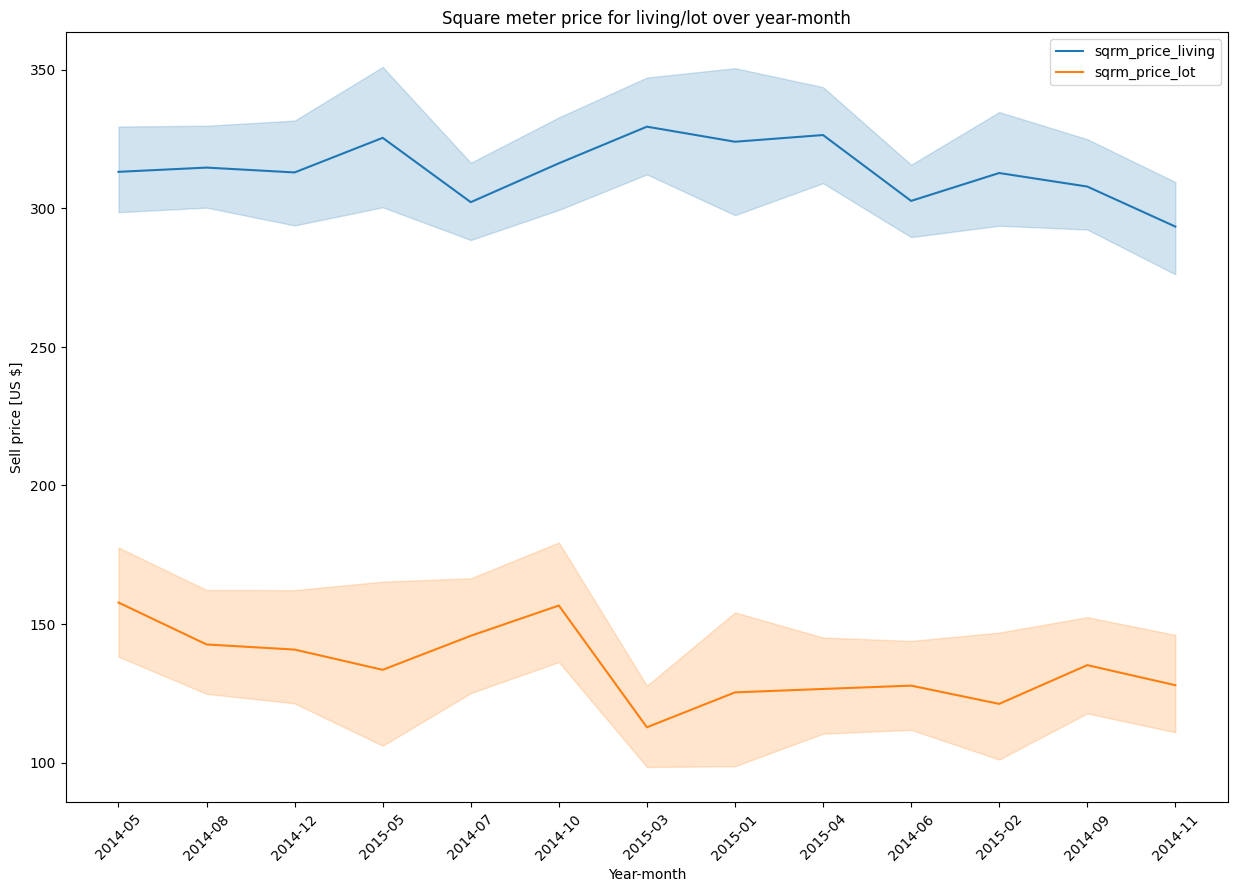

In [10]:
df_sqmt_price_lot_living = df_40_to_60.copy()
df_sqmt_price_lot_living["sqrm_price_living"] = df_sqmt_price_lot_living["sell_price"] / df_sqmt_price_lot_living["sqft_living"]
df_sqmt_price_lot_living["sqrm_price_living"] = df_sqmt_price_lot_living["sqrm_price_living"].round(2)

df_sqmt_price_lot_living["sqrm_price_lot"] = df_sqmt_price_lot_living["sell_price"] / df_sqmt_price_lot_living["sqft_lot"]
df_sqmt_price_lot_living["sqrm_price_lot"] = df_sqmt_price_lot_living["sqrm_price_lot"].round(2)
df_sqmt_price_lot_living


fig, ax = plt.subplots(figsize=(15, 10))
sns.lineplot(data=df_sqmt_price_lot_living, x="sell_year_month", y="sqrm_price_living", ax=ax, label="sqrm_price_living")
sns.lineplot(data=df_sqmt_price_lot_living, x="sell_year_month", y="sqrm_price_lot", ax=ax, label="sqrm_price_lot")
ax.set_title("Square meter price for living/lot over year-month")
ax.set_xlabel("Year-month")
ax.set_ylabel("Sell price [US $]")
plt.xticks(rotation=45) 

ax.legend() 

Second chart (scatter plot) for square feet living

(array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.,
        4500., 5000.]),
 [Text(0.0, 0, '0'),
  Text(500.0, 0, '500'),
  Text(1000.0, 0, '1000'),
  Text(1500.0, 0, '1500'),
  Text(2000.0, 0, '2000'),
  Text(2500.0, 0, '2500'),
  Text(3000.0, 0, '3000'),
  Text(3500.0, 0, '3500'),
  Text(4000.0, 0, '4000'),
  Text(4500.0, 0, '4500'),
  Text(5000.0, 0, '5000')])

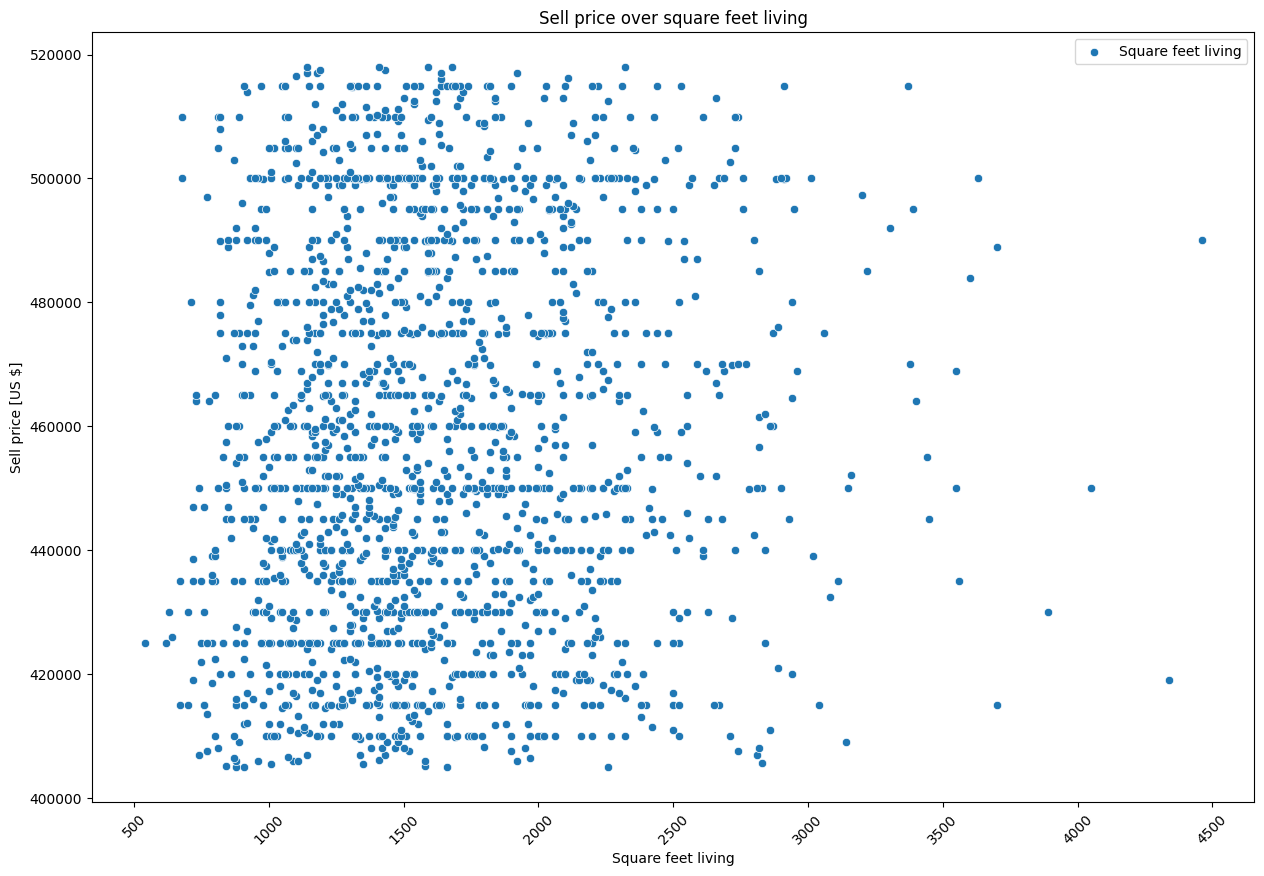

In [11]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df_40_to_60, x="sqft_living", y="sell_price", ax=ax, label="Square feet living")
ax.set_title("Sell price over square feet living")
ax.set_xlabel("Square feet living")
ax.set_ylabel("Sell price [US $]")
plt.xticks(rotation=45)

Third chart (scatter plot) for square feet lot

(array([-10000.,      0.,  10000.,  20000.,  30000.,  40000.,  50000.,
         60000.]),
 [Text(-10000.0, 0, '−10000'),
  Text(0.0, 0, '0'),
  Text(10000.0, 0, '10000'),
  Text(20000.0, 0, '20000'),
  Text(30000.0, 0, '30000'),
  Text(40000.0, 0, '40000'),
  Text(50000.0, 0, '50000'),
  Text(60000.0, 0, '60000')])

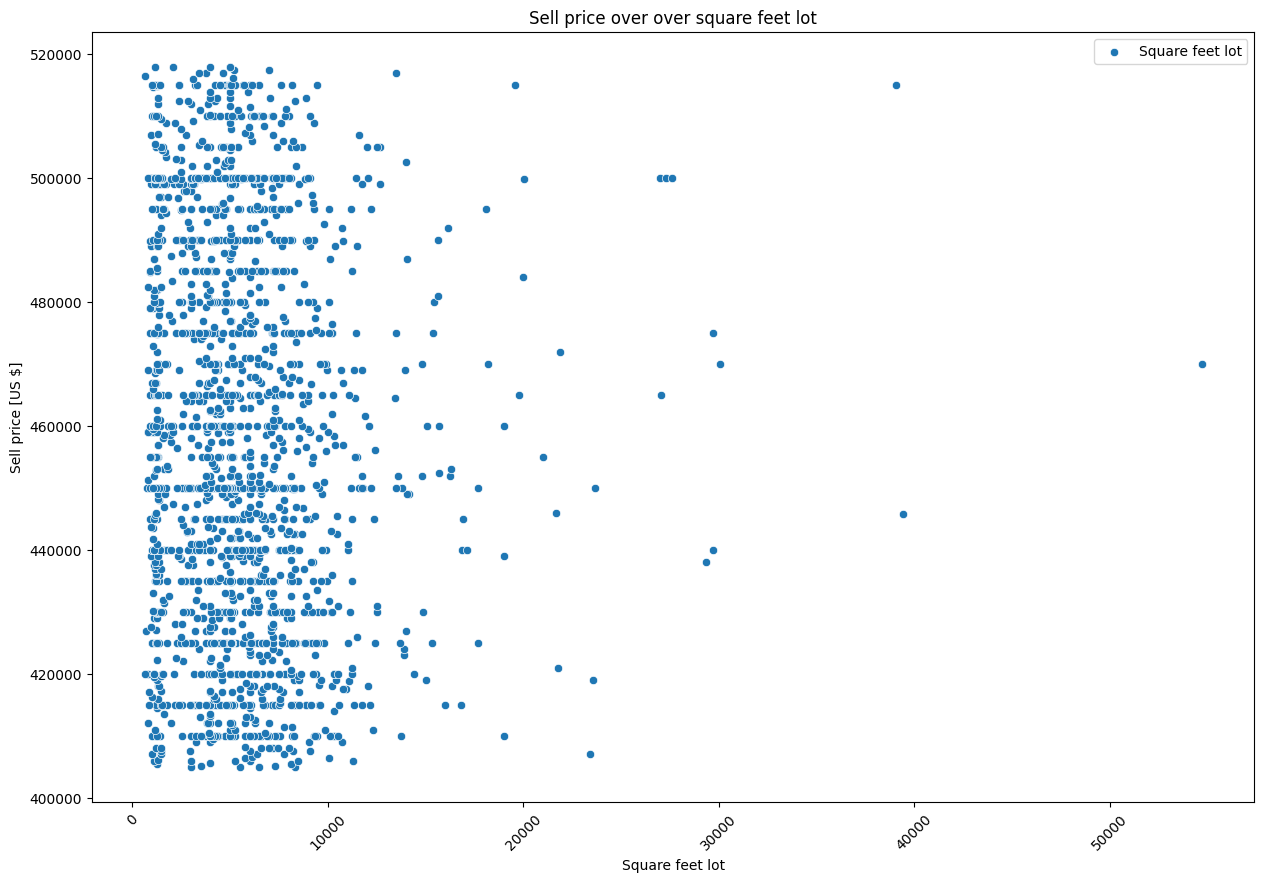

In [12]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df_40_to_60, x="sqft_lot", y="sell_price", ax=ax, label="Square feet lot")
ax.set_title("Sell price over over square feet lot")
ax.set_xlabel("Square feet lot")
ax.set_ylabel("Sell price [US $]")
plt.xticks(rotation=45) 

Histogram for sell prices by square meter price groups for living space

Text(0, 0.5, 'Sell price [US $]')

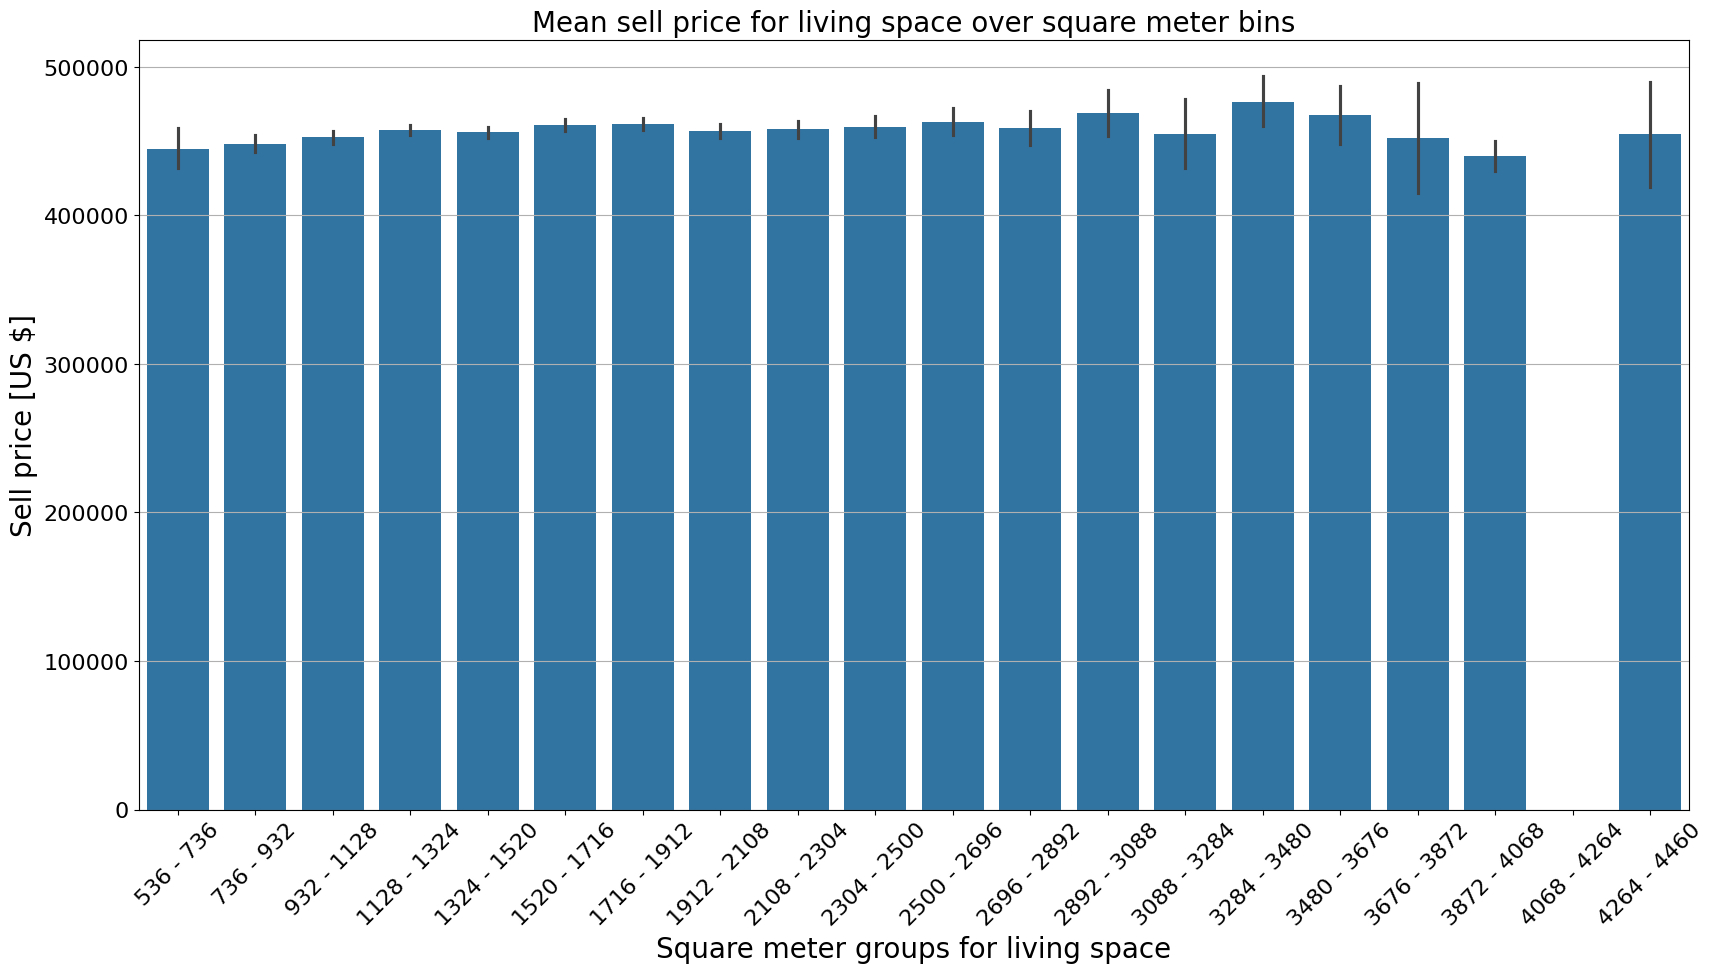

In [13]:
# Plot histogram
fig, ax = plt.subplots(figsize=(20, 10))

# Beispiel: Wir teilen die Wohnfläche (sqft_living) in 10 Bereiche ein
bins = pd.cut(df_40_to_60['sqft_living'], bins=20)
df_40_to_60['sqm_living_bins'] = bins.apply(lambda x: f"{int(x.left)} - {int(x.right)}")

# Seaborn berechnet hier standardmäßig den MEAN für y pro Bin
sns.barplot(data=df_40_to_60, x='sqm_living_bins', y='sell_price', estimator='mean')

ax.grid(axis='y')

plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.title("Mean sell price for living space over square meter bins", fontdict={"size": 20})
ax.set_xlabel("Square meter groups for living space", fontdict={"size": 20})
ax.set_ylabel("Sell price [US $]", fontdict={"size": 20})


Histogram for sell prices by square meter price groups for lot size

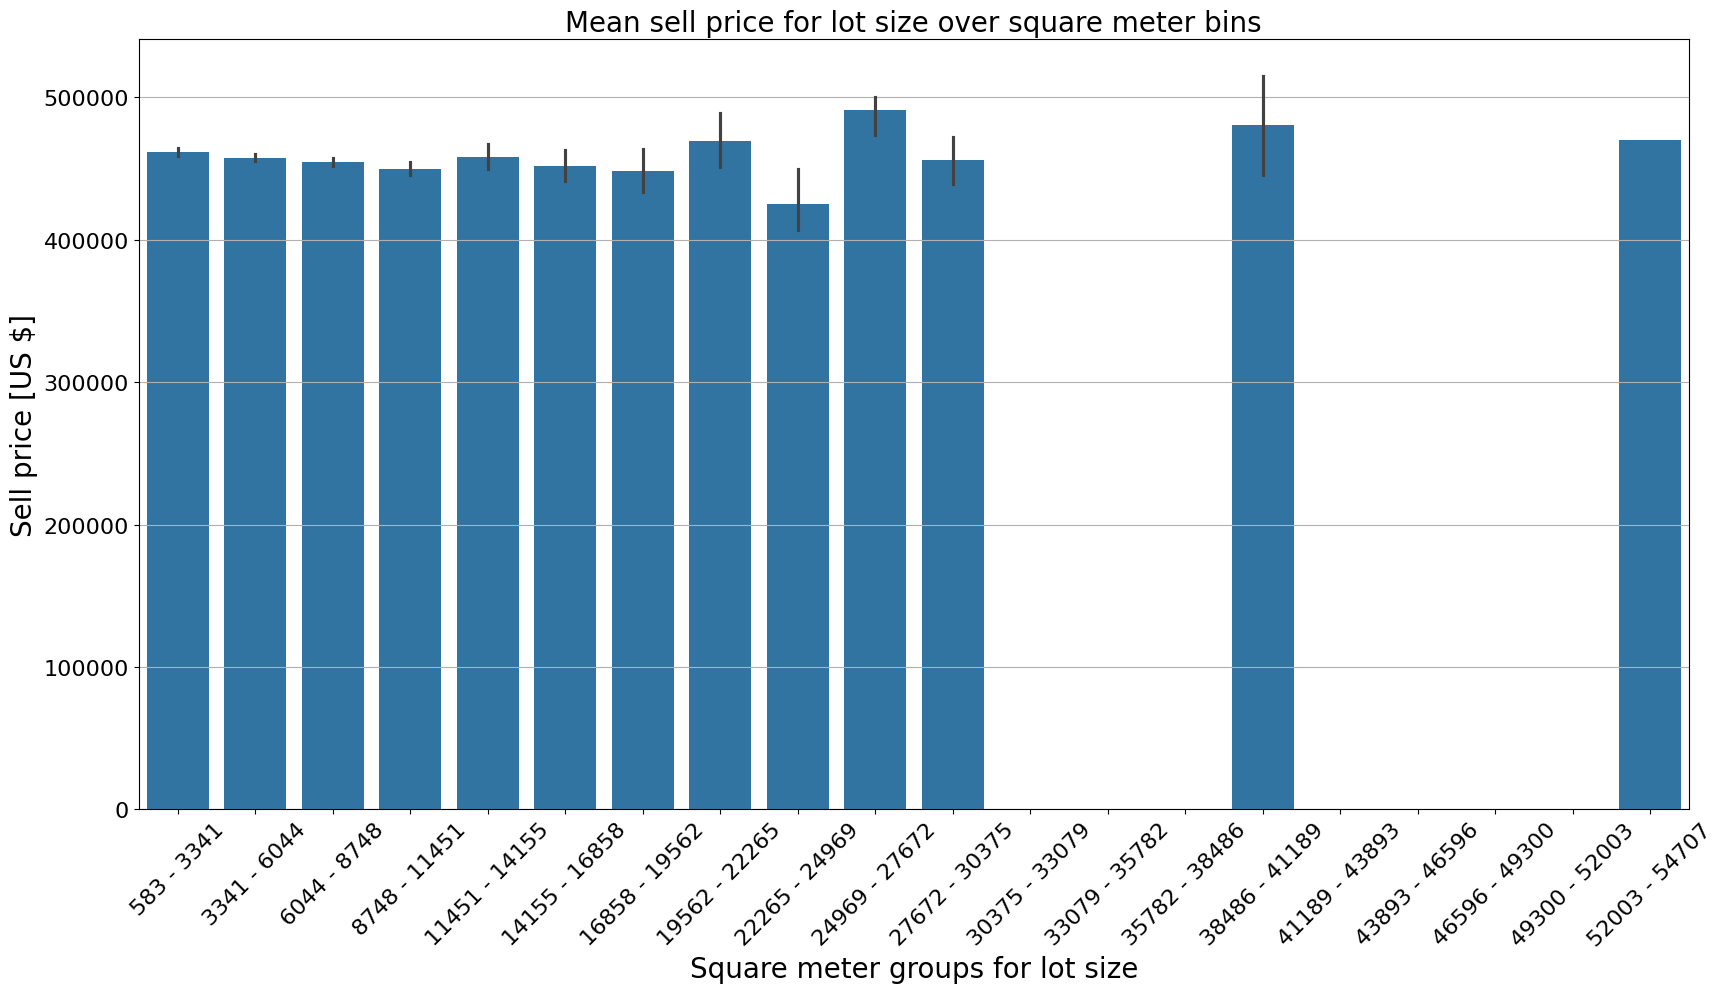

In [14]:
# Plot histogram
fig, ax = plt.subplots(figsize=(20, 10))

bins = pd.cut(df_40_to_60['sqft_lot'], bins=20)
df_40_to_60['sqm_lot_bins'] = bins.apply(lambda x: f"{int(x.left)} - {int(x.right)}")

# Seaborn berechnet hier standardmäßig den MEAN für y pro Bin
sns.barplot(data=df_40_to_60, x='sqm_lot_bins', y='sell_price', estimator='mean')

plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.title("Mean sell price for lot size over square meter bins", fontdict={"size": 20})
ax.set_xlabel("Square meter groups for lot size", fontdict={"size": 20})
ax.set_ylabel("Sell price [US $]", fontdict={"size": 20})

ax.grid(axis='y')


Second hypothesis:

First chart (heatmap) correlation of all variables corresponding to price to determine variable influence on housing price

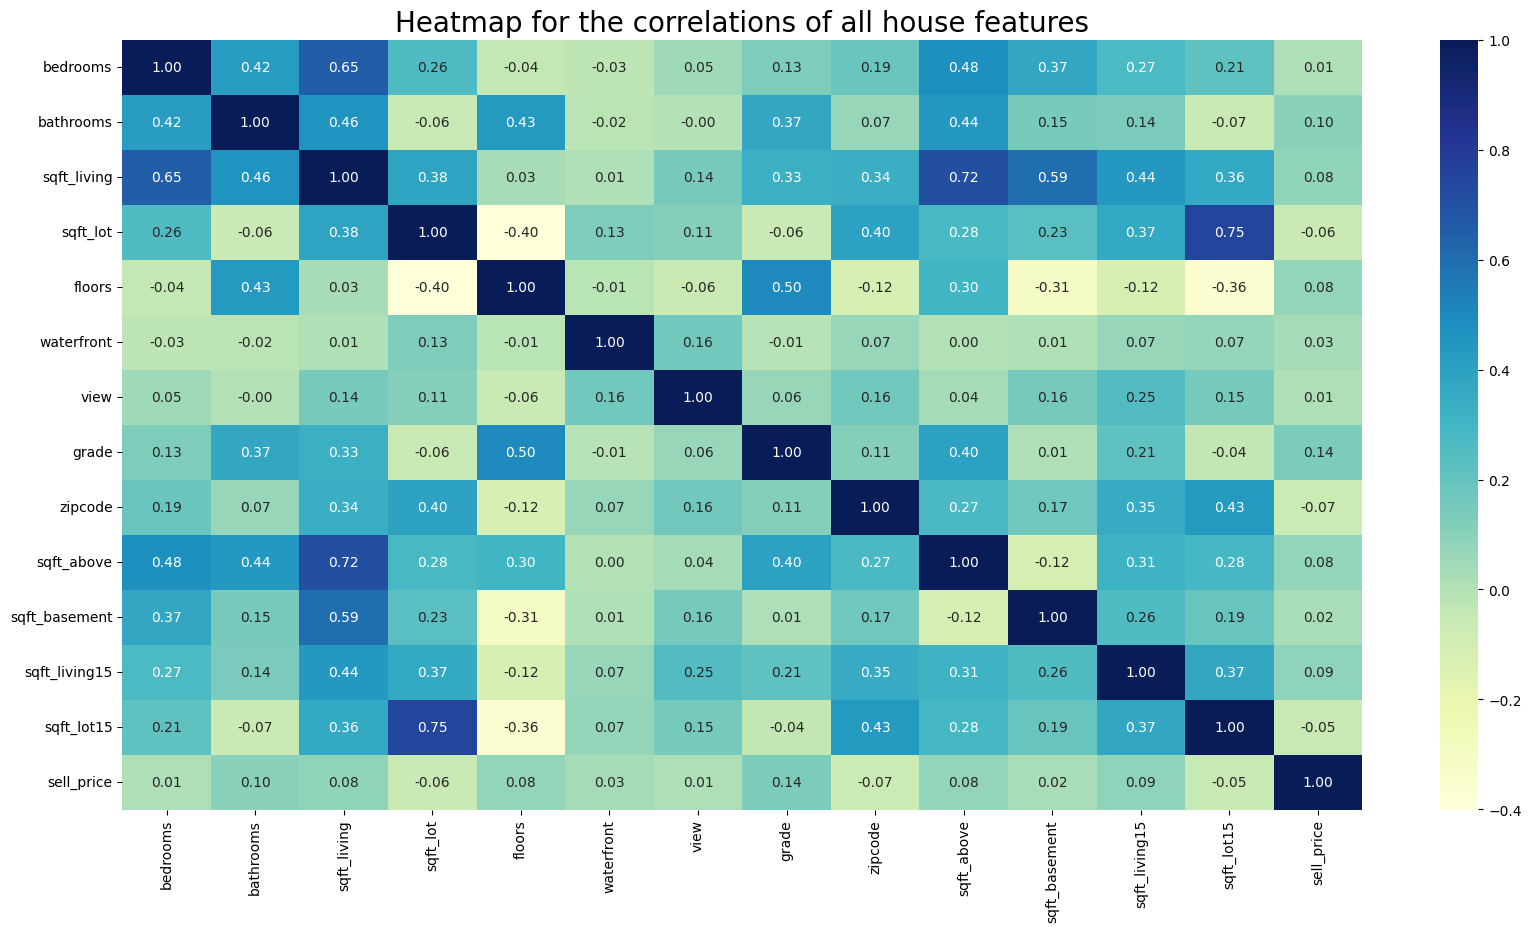

In [15]:
co_mtx = df_40_to_60[['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','grade','zipcode','sqft_above','sqft_basement','sqft_living15','sqft_lot15','sell_price']].corr(numeric_only=True)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt=".2f")

ax.set_title("Heatmap for the correlations of all house features", fontdict={"size": 20})

# Display heatmap
plt.show()

Correlation of house features to Selling Price

,sell_price
grade,0.135
bathrooms,0.099
sqft_living15,0.088
sqft_living,0.084
floors,0.080
sqft_above,0.076
waterfront,0.032
yr_built,0.028
sell_month,0.027
sqft_basement,0.023


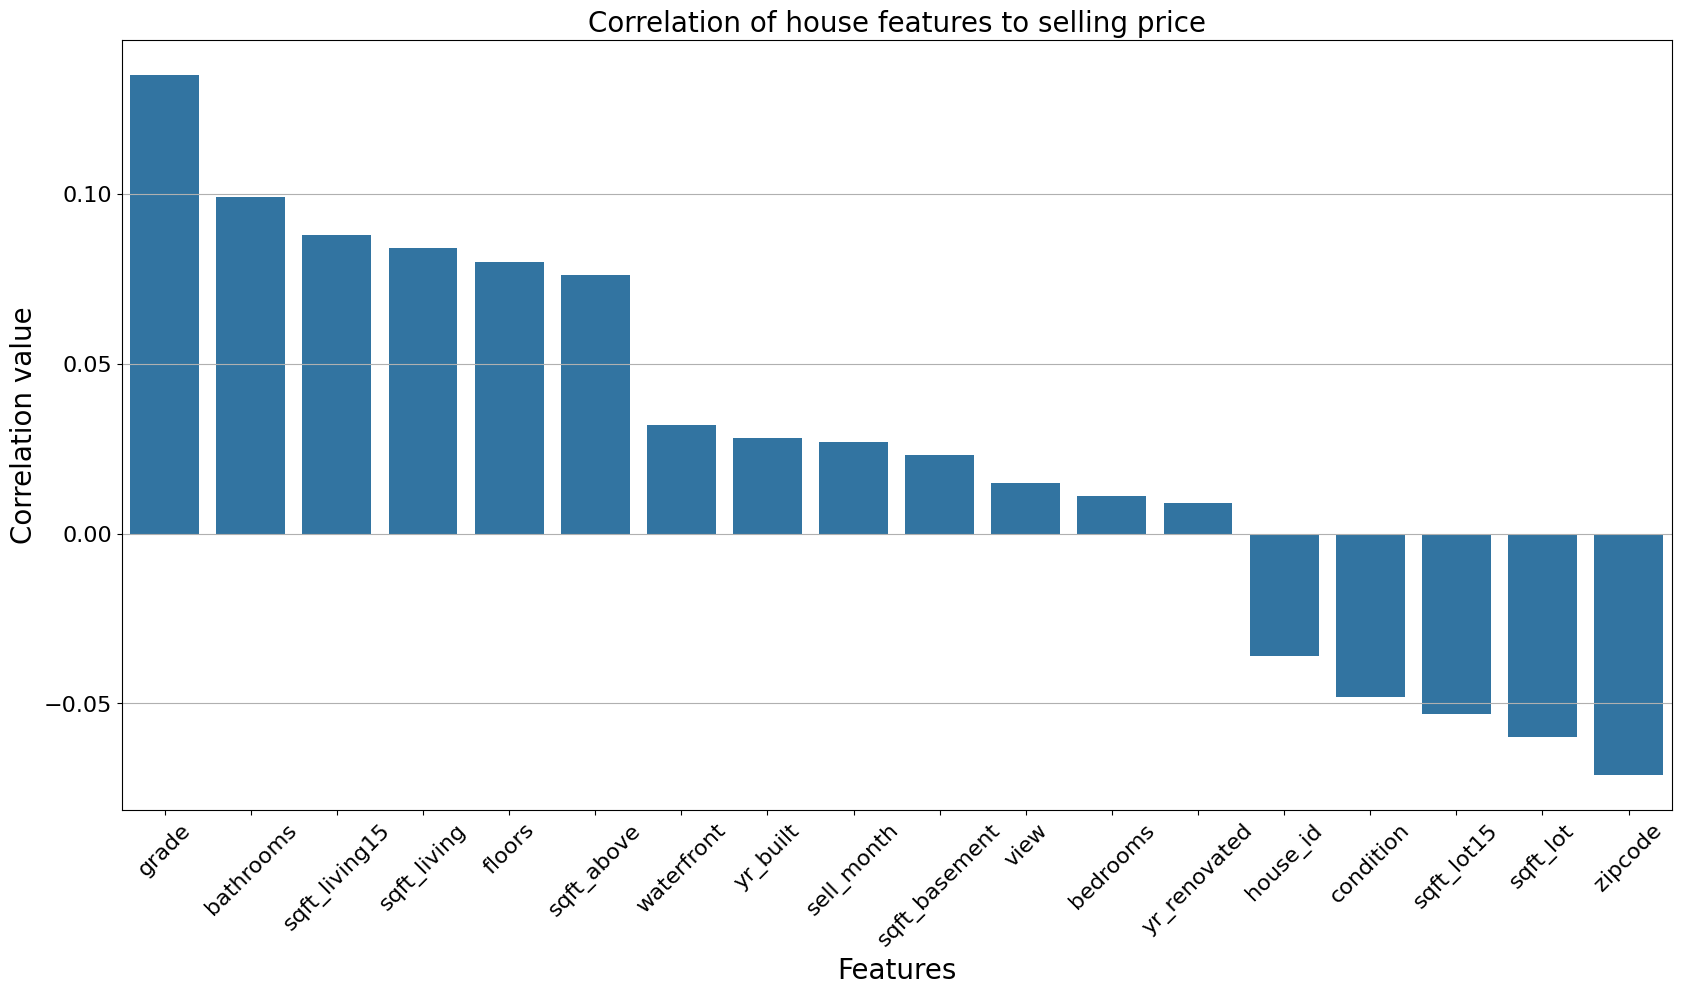

In [16]:
fig, ax = plt.subplots(figsize=(20, 10))
single_corr_df = df_40_to_60.corr(numeric_only=True)[['sell_price']].sort_values(by='sell_price', ascending=False)
single_corr_df = single_corr_df.drop(["sell_price", "lat", "long"])
single_corr_df["sell_price"] = single_corr_df["sell_price"].round(3)
ax.set_title("Correlation of house features to selling price", fontdict={"size": 20})
ax.set_xlabel("Features", fontdict={"size": 20})
ax.set_ylabel("Correlation value", fontdict={"size": 20})
sns.barplot(x=single_corr_df.index, y=single_corr_df["sell_price"])
plt.xticks(rotation=45, fontsize=16) 
plt.yticks(fontsize=16)
ax.grid(axis='y')
single_corr_df

Bar chart based on the grouped "year_month" column

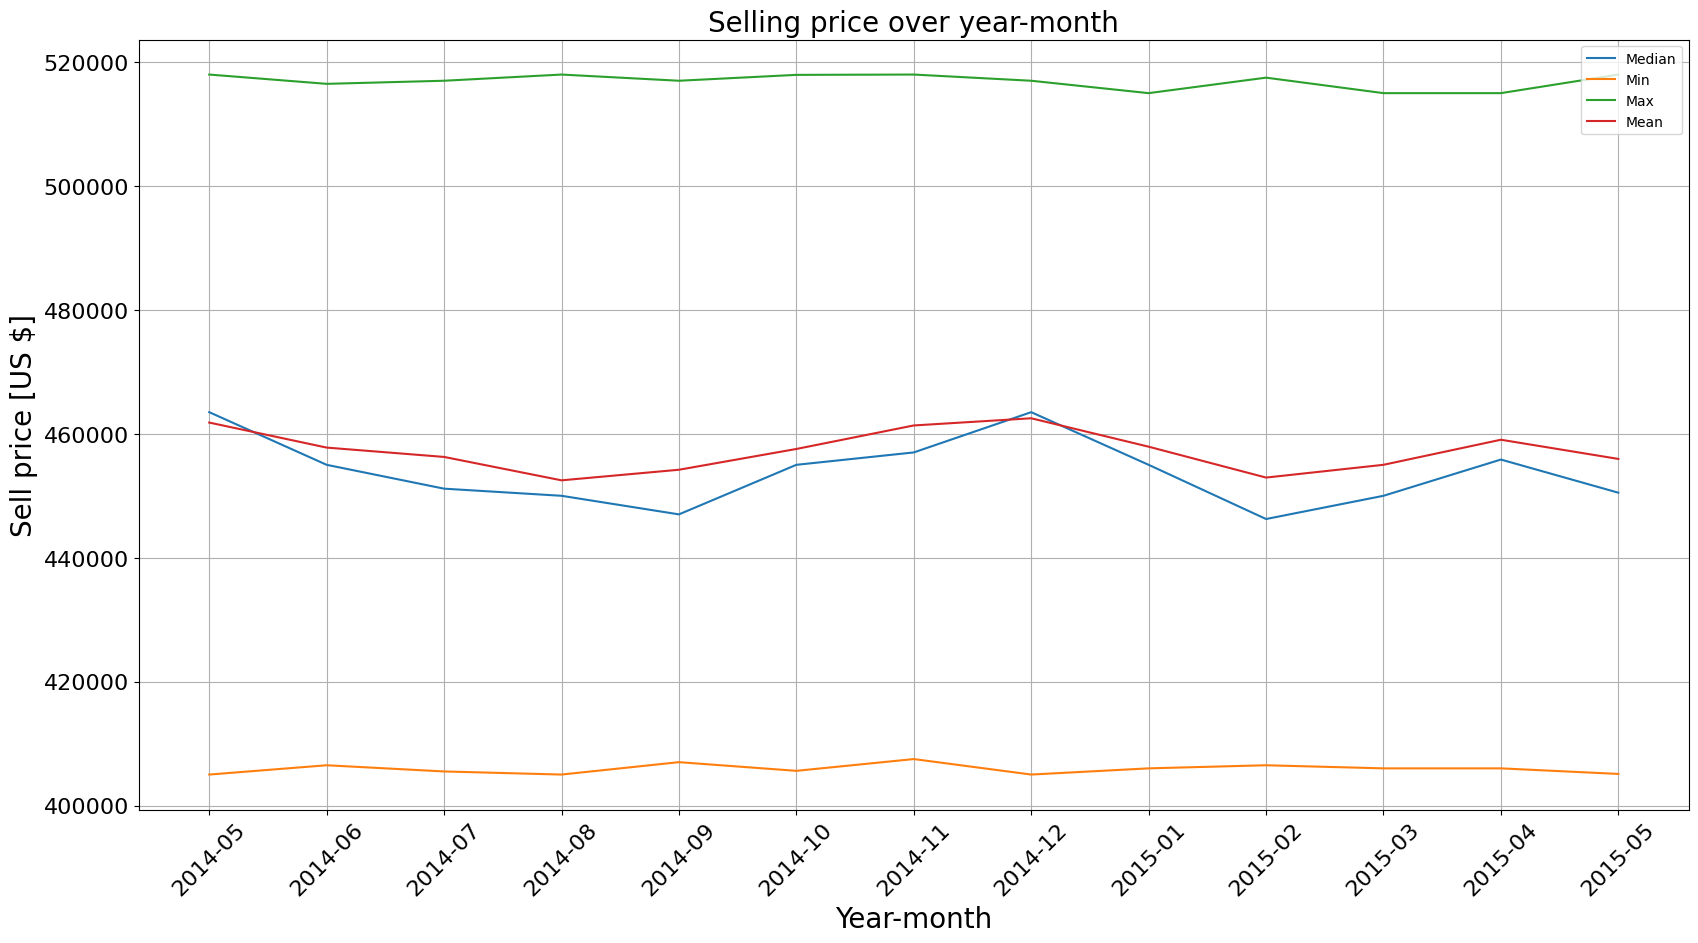

In [17]:
fig, ax = plt.subplots(figsize=(20, 10))
df_gb_year_month_median = df_40_to_60.groupby("sell_year_month")["sell_price"].median().to_frame()
df_gb_year_month_median.sort_values(by="sell_year_month")
sns.lineplot(data=df_gb_year_month_median, x="sell_year_month", y="sell_price", ax=ax, label="Median")
ax.set_title("Selling price over year-month", fontdict={"size": 20})
ax.set_xlabel("Year-month", fontdict={"size": 20})
ax.set_ylabel("Sell price [US $]", fontdict={"size": 20})

plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16) 

df_gb_year_month_min = df_40_to_60.groupby("sell_year_month")["sell_price"].min().to_frame()
df_gb_year_month_min.sort_values(by="sell_year_month")
sns.lineplot(data=df_gb_year_month_min, x="sell_year_month", y="sell_price", ax=ax, label="Min")

df_gb_year_month_max = df_40_to_60.groupby("sell_year_month")["sell_price"].max().to_frame()
df_gb_year_month_max.sort_values(by="sell_year_month")
sns.lineplot(data=df_gb_year_month_max, x="sell_year_month", y="sell_price", ax=ax, label="Max")

df_gb_year_month_mean = df_40_to_60.groupby("sell_year_month")["sell_price"].mean().to_frame()
df_gb_year_month_mean.sort_values(by="sell_year_month")
sns.lineplot(data=df_gb_year_month_mean, x="sell_year_month", y="sell_price", ax=ax, label="Mean")

ax.legend() 

ax.grid(axis='both')


Third hypothesis:

First chart (bar chart) mean and median housing price for the last two months (May and June) of the first half of the year and first two months (July and August) of the second half of the year 2014

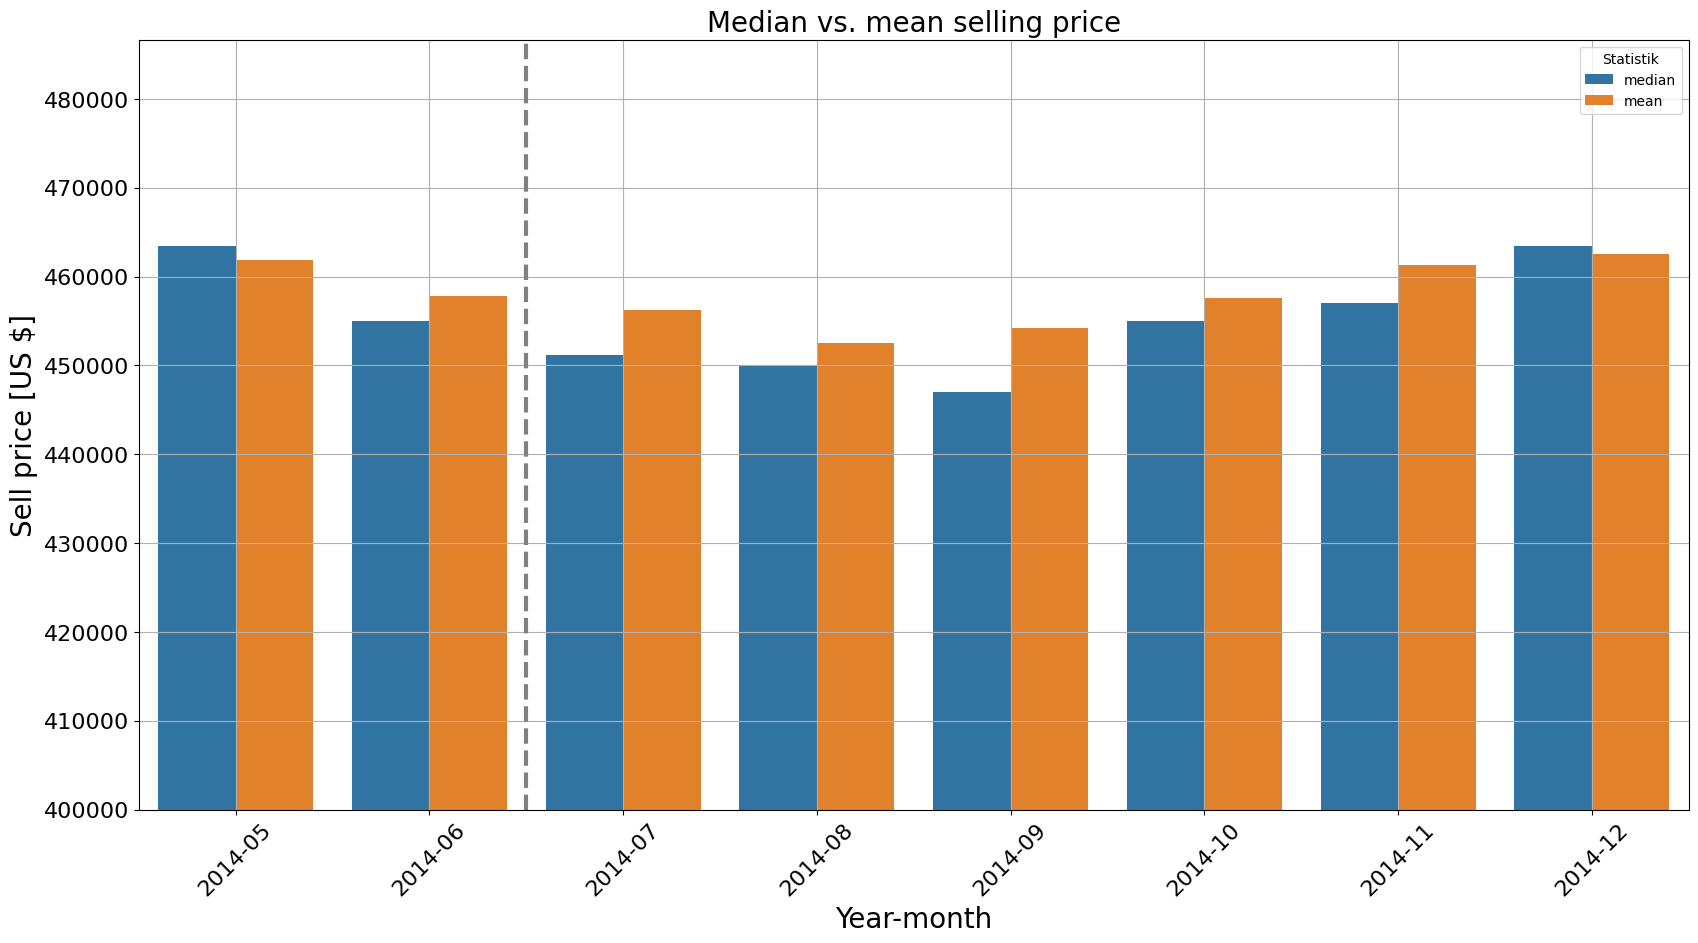

In [18]:


# Filter May to August 2014
months = ["2014-05", "2014-06", "2014-07", "2014-08", "2014-09", "2014-10", "2014-11", "2014-12",]
df_filtered = df_40_to_60[df_40_to_60["sell_year_month"].isin(months)]

# Group by Sell Year Month and calculate mean and median for this group by
df_stats = df_filtered.groupby("sell_year_month")["sell_price"].agg(["median", "mean"]).reset_index()

# 
df_plot = df_stats.melt(id_vars="sell_year_month", var_name="Statistik", value_name="Preis")

fig, ax = plt.subplots(figsize=(20, 10))

# hue for plotting the bars next to each other instead of over each other
sns.barplot(data=df_plot, x="sell_year_month", y="Preis", hue="Statistik", ax=ax)

ax.set_title("Median vs. mean selling price", fontdict={"size": 20})
ax.set_xlabel("Year-month", fontdict={"size": 20})
ax.set_ylabel("Sell price [US $]", fontdict={"size": 20})
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

# added a vertical line for border of first and second half of the year
ax.axvline(x=1.5, color='grey', linestyle='--', linewidth=3)

# for better visibility start at 400000
ax.set_ylim(bottom=400000)

ax.grid(axis='both')

plt.show()

Additional chart which is not related to one of the hypothesis, but it's good general recommendation.
Bar chart for the square meter prices groubed by zip code.

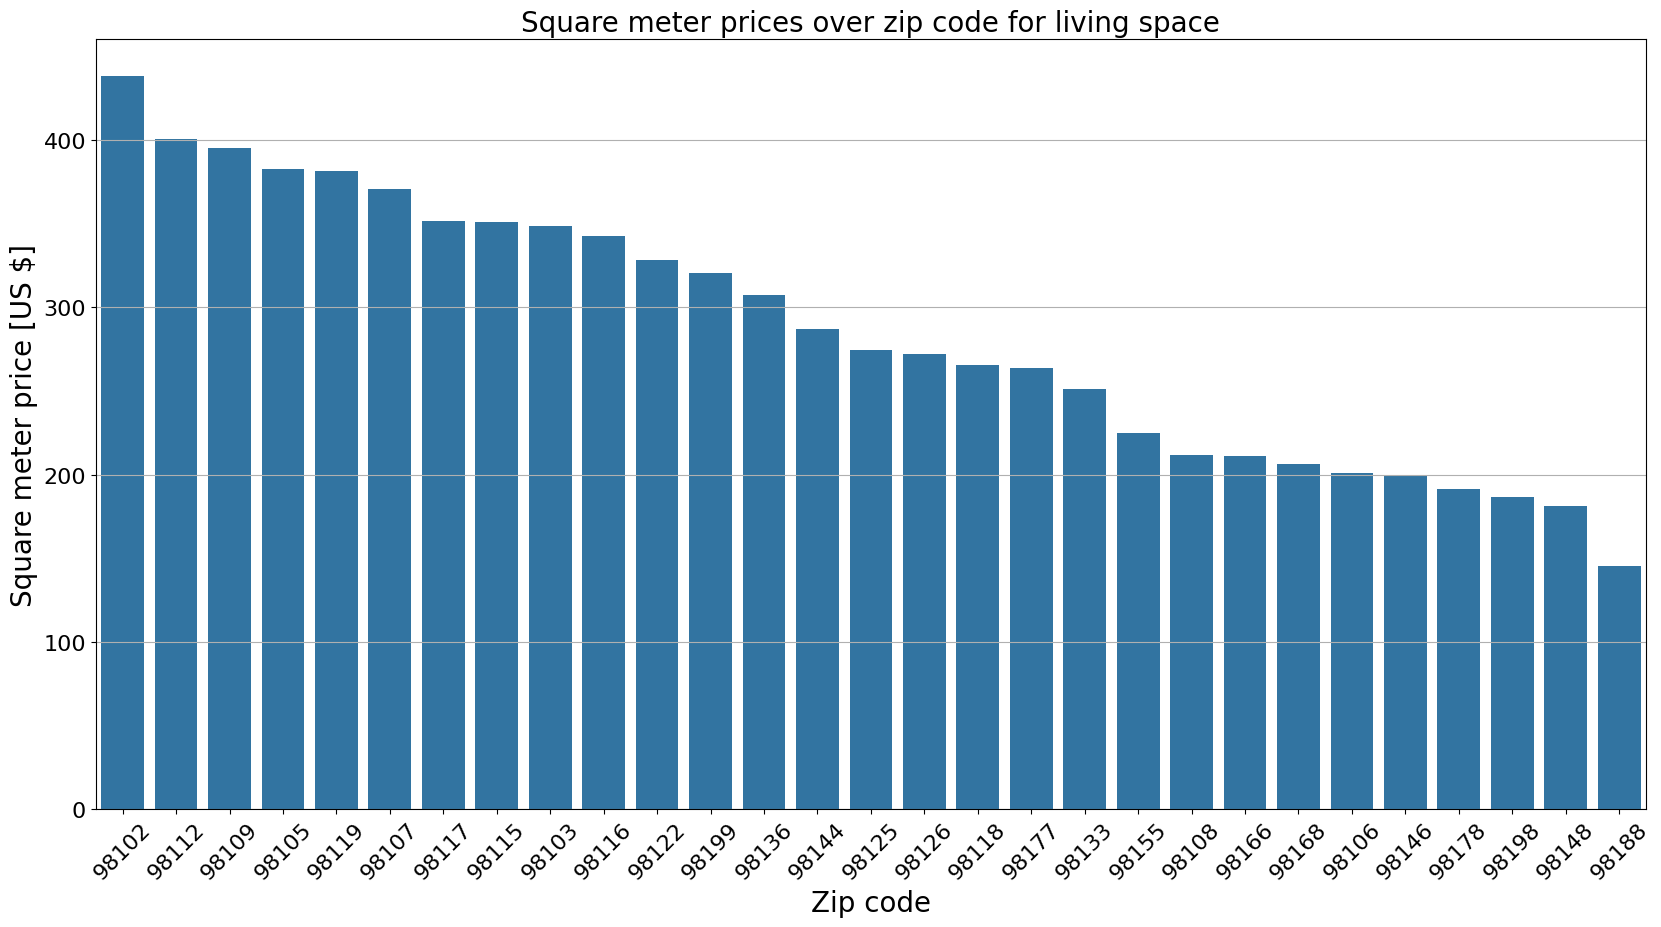

,zipcode,sqrm_price_living
0,98102,438.14
7,98112,400.49
6,98109,395.26
2,98105,382.57
12,98119,381.36
4,98107,370.46
10,98117,351.80
8,98115,351.22
1,98103,348.84
9,98116,342.42


In [19]:
# Group by zip code and sort descending by the sell price
df_sm_price_by_zipcode_living = (
    df_sqmt_price_lot_living
    .groupby("zipcode")["sqrm_price_living"]
    .median()
    .round(2)
    .reset_index()
    .sort_values(by="sqrm_price_living", ascending=False)
)

fig, ax = plt.subplots(figsize=(20, 10))


sns.barplot(
    data=df_sm_price_by_zipcode_living, 
    x="zipcode",                        
    y="sqrm_price_living",             
    ax=ax,
    order=df_sm_price_by_zipcode_living["zipcode"]  
)

ax.set_title("Square meter prices over zip code for living space", fontdict={"size": 20})
ax.set_xlabel("Zip code", fontdict={"size": 20})
ax.set_ylabel("Square meter price [US $]", fontdict={"size": 20})
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
ax.grid(axis='y')
plt.show()
df_sm_price_by_zipcode_living


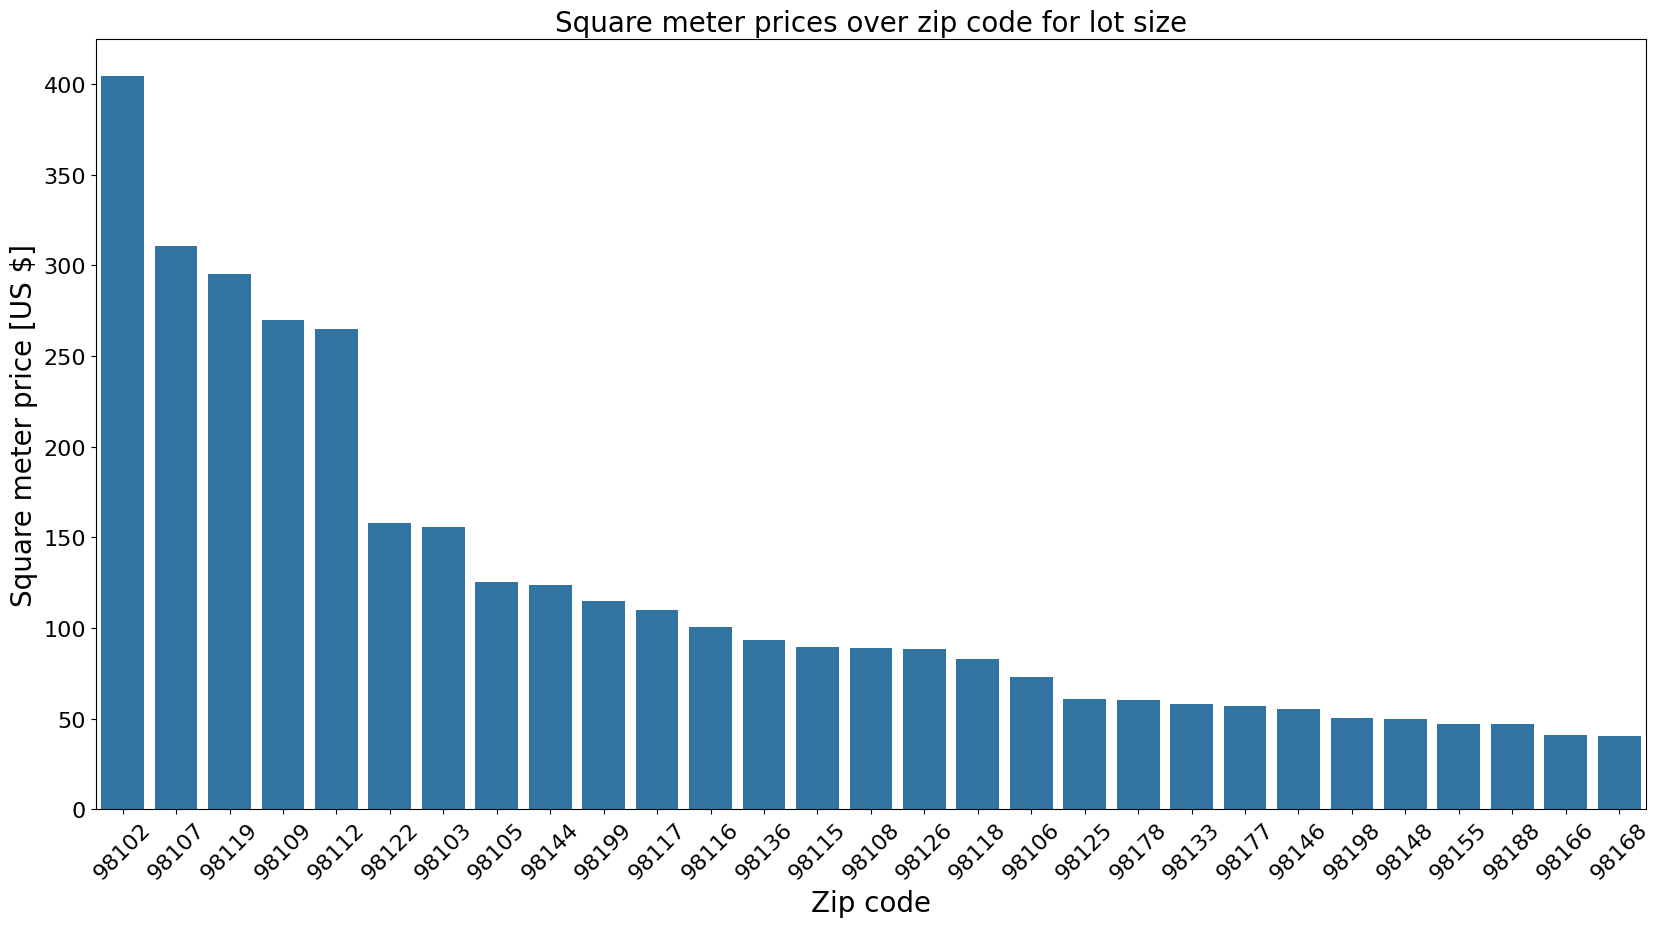

,zipcode,sqrm_price_lot
0,98102,404.41
4,98107,310.87
12,98119,295.24
6,98109,270.09
7,98112,264.76
13,98122,157.91
1,98103,155.71
2,98105,125.60
18,98144,123.75
28,98199,115.00


In [20]:
# Group by zip code and sort descending by the sell price
df_sm_price_by_zipcode_lot = (
    df_sqmt_price_lot_living
    .groupby("zipcode")[["sqrm_price_lot"]]
    .median()
    .round(2)
    .reset_index()
    .sort_values(by="sqrm_price_lot", ascending=False)
)

fig, ax = plt.subplots(figsize=(20, 10))


sns.barplot(
    data=df_sm_price_by_zipcode_lot, 
    x="zipcode",                        
    y="sqrm_price_lot",             
    ax=ax,
    order=df_sm_price_by_zipcode_lot["zipcode"]  
)

ax.set_title("Square meter prices over zip code for lot size", fontdict={"size": 20})
ax.set_xlabel("Zip code", fontdict={"size": 20})
ax.set_ylabel("Square meter price [US $]", fontdict={"size": 20})
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.show()
df_sm_price_by_zipcode_lot

Recommendation for zipcode

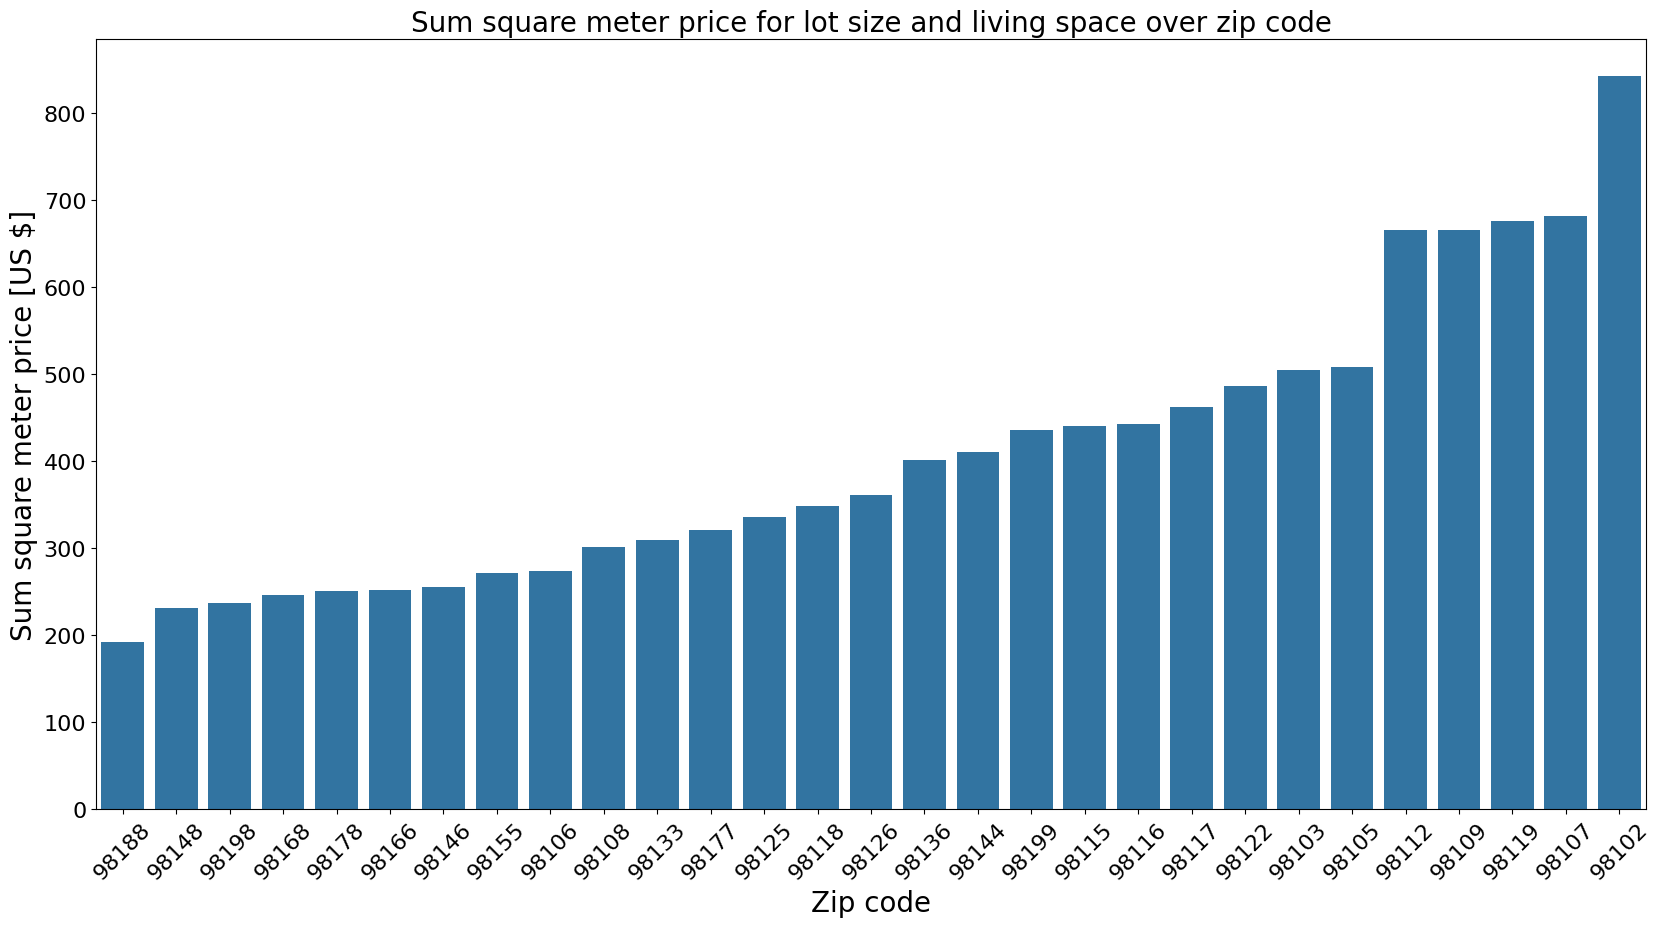

In [21]:
df_sqmt_price_group_by = df_sqmt_price_lot_living.groupby("zipcode")[['sqrm_price_living','sqrm_price_lot']].median()
df_sqmt_price_group_by['sum_per_zipcode'] = df_sqmt_price_group_by['sqrm_price_living'] + df_sqmt_price_group_by['sqrm_price_lot']
df_sqmt_price_group_by = df_sqmt_price_group_by.sort_values(by='sum_per_zipcode',ascending=True)

df_sqmt_price_group_by.index

fig, ax = plt.subplots(figsize=(20, 10))

sns.barplot(
    data=df_sqmt_price_group_by, 
    x=df_sqmt_price_group_by.index,                        
    y="sum_per_zipcode",             
    ax=ax,
    order=df_sqmt_price_group_by.index 
)

ax.set_title("Sum square meter price for lot size and living space over zip code", fontdict={"size": 20})
ax.set_xlabel("Zip code", fontdict={"size": 20})
ax.set_ylabel("Sum square meter price [US $]", fontdict={"size": 20})
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

plt.show()

98188 is the cheapest zip code in Seattle!